# Exploring Spatial Microenvironments with ReCoN

This tutorial demonstrates how to compare **cell-type-specific regulation between spatial microenvironments**. Starting from a Visium slide and a single-cell reference, you will learn how to:

1. Deconvolve mixed Visium spots with cell2location
2. Create spot–cell-type expression profiles
3. Identify niches representing different cellular contexts
4. Infer a cell-cell communication network in each niche
5. Build one ReCoN model per niche
6. Compare the predicted fibroblast response between two niches

**Use case**: Given a spatial slide, determine how the same cell type—here, fibroblasts—is regulated differently across local tissue contexts.

> This mini tutorial is adapted from the [Spatial Heart Microenvironments showcase](https://github.com/cantinilab/recon_reproducibility/tree/main/showcases_paper/Spatial_Heart_Microenvironments) in the [`recon_reproducibility`](https://github.com/cantinilab/recon_reproducibility) repository.

```{note}
This workflow is written for **spot-based Visium data**, where each observation mixes transcripts from multiple cells. Imaging-based assays with segmented cell-level expression, such as Xenium, usually do not require the cell2location deconvolution and spot–cell-type reconstruction steps. For those assays, begin with quality-controlled, cell-annotated expression profiles and spatial coordinates, then define niches and continue with niche-specific communication and ReCoN analyses.
```

```{image} ../../../figures/recon_tutorial_6_overview.png
:alt: Overview of the spatial niche comparison workflow, from Visium deconvolution to niche-specific ReCoN models
:align: center
:width: 100%
```

## Setup

Spatial preprocessing uses optional packages that ReCoN itself does not require. Full cell2location training can take substantial time and benefits from a GPU.

```bash
conda create -n recon-spatial python=3.10
conda activate recon-spatial
pip install recon scanpy liana cell2location scvi-tools==1.2.2
```

```{warning}
cell2location may require older versions of scientific Python dependencies than a current ReCoN installation, which can create dependency conflicts in a shared environment. The combined environment above is convenient when its dependencies resolve successfully, but it is not required.

A robust alternative is to run sections 1–2 in a dedicated cell2location environment, save the deconvolved Visium object—including the cell-type abundance estimates in `adata_vis.obsm["q05_cell_abundance_w_sf"]`—and then load that `.h5ad` file in a separate, newly created ReCoN environment to continue from section 3. This keeps the deconvolution and ReCoN dependency stacks isolated without changing the downstream analysis.
```

In [1]:
from pathlib import Path

import anndata as ad
import cell2location
import liana as li
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
from scipy import sparse

import recon.data
import recon.explore

DATA_DIR = Path("./data/spatial_tuto")
SLIDE = "Visium_18"

SPATIAL_FILES = [
    "spatial_tuto/reference_heart_4k.h5ad",
    "spatial_tuto/visium18_all_spots_4k_genes.h5ad",
    "spatial_tuto/heart_grn_top250k.csv",
]
for filename in SPATIAL_FILES:
    recon.data.fetch_tutorial_data(filename, data_dir="./data")

/pasteur/appa/homes/rtrimbou/miniconda3/envs/snakemake/envs/cell2location/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load Visium and learn cell-type signatures

A Visium spot measures the combined expression of several nearby cells. A single-cell reference supplies cell-type labels and expression signatures that cell2location uses to decompose this mixture. Both objects must contain raw counts and compatible gene identifiers.

cell2location first learns an average expression signature for every reference cell type. This separates cell-type signatures from sample and technical effects before mapping them onto the slide.

/pasteur/appa/homes/rtrimbou/miniconda3/envs/snakemake/envs/cell2location/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10


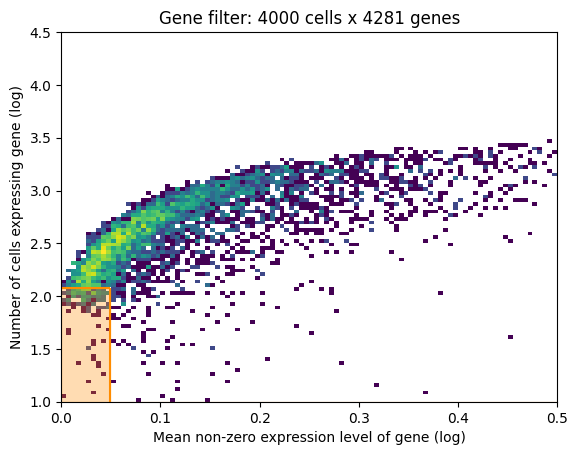

/pasteur/appa/homes/rtrimbou/miniconda3/envs/snakemake/envs/cell2location/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: PossibleUserWarning: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /pasteur/appa/homes/rtrimbou/miniconda3/envs/snakema ...
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/pasteur/appa/homes/rtrimbou/miniconda3/envs/snakemake/envs/cell2location/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: PossibleUserWarning: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /pasteur/appa/homes/rtrimbou/miniconda3/envs/snakema ...
/pasteur/appa/homes/rtrimbou/miniconda3/envs/snakemake/envs/cell2

Epoch 25/25: 100%|██████████| 25/25 [02:15<00:00,  5.47s/it, v_num=1, elbo_train=8.74e+6]

`Trainer.fit` stopped: `max_epochs=25` reached.


Epoch 25/25: 100%|██████████| 25/25 [02:15<00:00,  5.40s/it, v_num=1, elbo_train=8.74e+6]

/pasteur/appa/homes/rtrimbou/miniconda3/envs/snakemake/envs/cell2location/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: PossibleUserWarning: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /pasteur/appa/homes/rtrimbou/miniconda3/envs/snakema ...



Sampling global variables, sample: 100%|██████████| 999/999 [03:28<00:00,  4.79it/s]


In [2]:
from cell2location.utils.filtering import filter_genes

# The bundled reference contains raw counts for 4,000 cells, balanced across
# all seven modeled cell types and covering all 29 reference samples.
adata_vis = sc.read_h5ad(DATA_DIR / "visium18_all_spots_4k_genes.h5ad")
adata_ref = sc.read_h5ad(DATA_DIR / "reference_heart_4k.h5ad")
adata_vis.obs["sample"] = list(adata_vis.uns["spatial"])[0]

selected = filter_genes(adata_ref, cell_count_cutoff=5,
                        cell_percentage_cutoff2=0.03, nonz_mean_cutoff=1.12)
adata_ref = adata_ref[:, selected].copy()
cell2location.models.RegressionModel.setup_anndata(
    adata_ref, batch_key="sample", labels_key="cell_type_original"
)
reference_model = cell2location.models.RegressionModel(adata_ref)
reference_model.train(max_epochs=25, train_size=1, batch_size=4000)
adata_ref = reference_model.export_posterior(
    adata_ref, sample_kwargs={"num_samples": 1000, "batch_size": 2500}
)

factor_names = adata_ref.uns["mod"]["factor_names"]
if "means_per_cluster_mu_fg" in adata_ref.varm:
    signatures = adata_ref.varm["means_per_cluster_mu_fg"].copy()
    signatures.columns = factor_names
else:
    columns = [f"means_per_cluster_mu_fg_{x}" for x in factor_names]
    signatures = adata_ref.var[columns].copy()
    signatures.columns = factor_names

### Map cell types onto Visium spots

The spatial model explains each spot as a mixture of the learned signatures. Its posterior estimates both cell-type abundance and the expression attributable to each cell type in each spot.

In [3]:
shared_genes = adata_vis.var_names.intersection(signatures.index)
adata_vis = adata_vis[:, shared_genes].copy()
signatures = signatures.loc[shared_genes]

cell2location.models.Cell2location.setup_anndata(adata_vis, batch_key="sample")
spatial_model = cell2location.models.Cell2location(
    adata_vis, cell_state_df=signatures,
    N_cells_per_location=30, detection_alpha=20,
)
spatial_model.train(max_epochs=100, batch_size=None, train_size=1)
adata_vis = spatial_model.export_posterior(
    adata_vis,
    sample_kwargs={"num_samples": 1000, "batch_size": adata_vis.n_obs},
)
celltypes = list(spatial_model.factor_names_)
adata_vis.obs[celltypes] = adata_vis.obsm["q05_cell_abundance_w_sf"]

/pasteur/appa/homes/rtrimbou/miniconda3/envs/snakemake/envs/cell2location/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: PossibleUserWarning: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /pasteur/appa/homes/rtrimbou/miniconda3/envs/snakema ...
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/pasteur/appa/homes/rtrimbou/miniconda3/envs/snakemake/envs/cell2location/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: PossibleUserWarning: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /pasteur/appa/homes/rtrimbou/miniconda3/envs/snakema ...
/pasteur/appa/homes/rtrimbou/miniconda3/envs/snakemake/envs/cell2

Epoch 100/100: 100%|██████████| 100/100 [03:41<00:00,  2.17s/it, v_num=1, elbo_train=3.66e+7]

`Trainer.fit` stopped: `max_epochs=100` reached.


Epoch 100/100: 100%|██████████| 100/100 [03:41<00:00,  2.22s/it, v_num=1, elbo_train=3.66e+7]

/pasteur/appa/homes/rtrimbou/miniconda3/envs/snakemake/envs/cell2location/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: PossibleUserWarning: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /pasteur/appa/homes/rtrimbou/miniconda3/envs/snakema ...



Sampling global variables, sample: 100%|██████████| 999/999 [04:17<00:00,  3.89it/s]


```{warning}
**Reduced settings for a runnable tutorial**

The spatial mapping above uses `max_epochs=100`, whereas the full reproducibility showcase trained this model for 10,000 epochs. This low value is intended to demonstrate the workflow quickly and should not be treated as a production default. For a real analysis, increase the epoch limit and inspect the training history to confirm that the loss has stabilized; the required value depends on the dataset. A correctly configured GPU can greatly **reduce** cell2location training and posterior-sampling time, making longer training practical. The reference-signature model uses 25 epochs, as in the showcase, but convergence should still be checked on a new reference.
```

```{note}
**About the bundled data**

The tutorial keeps the complete Visium slide: all 3,572 spots and all nine published niches. Only the gene axis is reduced to 4,500 genes, including every ligand and receptor used in the two-niche comparison. Spatial adjacency, coordinates, and image metadata are retained.

The single-cell reference is reduced to 4,000 cells by stratified sampling, with 571–572 cells per modeled cell type and representation from all 29 samples. See `data/spatial_tuto/README.md` for provenance and checksums.
```

## 2. Identify spatial niches

A niche groups spatial spots with similar inferred cellular composition. Niches define the different biological contexts that ReCoN will model. Without them, communication from distinct tissue regions would be pooled into one slide-wide network, hiding context-specific regulation.

/local/scratch/tmp/ipykernel_965447/3574933244.py:2: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
/local/scratch/tmp/ipykernel_965447/3574933244.py:7: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
... storing 'sample' as categorical


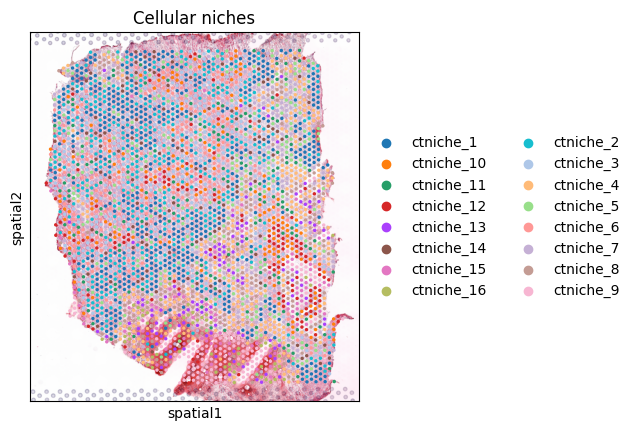

,Cardiomyocyte,Endothelial,Fibroblast,Lymphoid,Myeloid,Pericyte,vSMCs
celltype_niche,,,,,,,
ctniche_1,0.142471,0.143057,0.142796,0.142839,0.142792,0.143098,0.142947
ctniche_10,0.125846,0.151550,0.148582,0.146090,0.129903,0.155283,0.142746
ctniche_11,0.113173,0.149012,0.148927,0.147252,0.144865,0.150347,0.146423
ctniche_12,0.127611,0.148379,0.149678,0.139181,0.135737,0.161457,0.137957
ctniche_13,0.112072,0.150177,0.152905,0.145550,0.158567,0.154508,0.126220
ctniche_14,0.140616,0.143205,0.143583,0.143167,0.142198,0.143702,0.143529
ctniche_15,0.138126,0.142646,0.145084,0.142050,0.146790,0.144630,0.140674
ctniche_16,0.128597,0.140373,0.140359,0.139150,0.177223,0.141887,0.132411
ctniche_2,0.142790,0.143244,0.142881,0.142649,0.142539,0.143383,0.142515


In [4]:
sc.pp.neighbors(adata_vis, use_rep="q05_cell_abundance_w_sf", n_neighbors=15)
sc.tl.leiden(adata_vis, resolution=1.1, key_added="celltype_niche")
adata_vis.obs["celltype_niche"] = (
    "ctniche_" + (adata_vis.obs["celltype_niche"].astype(int) + 1).astype(str)
).astype("category")

sc.pl.spatial(adata_vis, color="celltype_niche", title="Cellular niches")
niche_composition = adata_vis.obs.groupby("celltype_niche", observed=True)[celltypes].mean()
niche_composition.div(niche_composition.sum(axis=1), axis=0)

```{important}
Niche numbers are arbitrary cluster labels. Characterize niches from their composition and location before selecting a contrast; a newly generated `ctniche_1` does not necessarily match publication niche 1. The fast path retains the publication labels.
```

```{image} ../../../figures/recon_tutorial_6_deconvolution.png
:alt: Visium spots are deconvolved into cell-type-specific expression profiles within spatial niches
:align: center
:width: 100%
```


## 3. Create spot–cell-type expression profiles

Visium provides one mixed expression vector per spot, whereas ReCoN must distinguish ligand-producing and receptor-bearing cell types. cell2location deconvolution lets us estimate one expression vector for every **spot–cell-type pair**. These profiles restore cell-type resolution while preserving the spot's niche and coordinates. They are model-based estimates, not physically isolated single cells.

In [9]:
expected = spatial_model.module.model.compute_expected_per_cell_type(
    spatial_model.samples["post_sample_q05"], spatial_model.adata_manager
)

profile_matrices, profile_obs = [], []
for i, celltype in enumerate(celltypes):
    attributed = expected["mu"][i]
    abundance = np.asarray(adata_vis.obs[celltype]).clip(min=1e-8)
    normalized = (attributed.multiply(1 / abundance[:, None])
                  if sparse.issparse(attributed)
                  else attributed / abundance[:, None])
    profile_matrices.append(normalized)
    profile_obs.append(pd.DataFrame({
        "spot": adata_vis.obs_names,
        "cell_type": celltype,
        "celltype_niche": adata_vis.obs["celltype_niche"].to_numpy(),
    }, index=[f"{celltype}::{spot}" for spot in adata_vis.obs_names]))

profiles = ad.AnnData(
    X=sparse.vstack(profile_matrices, format="csr"),
    obs=pd.concat(profile_obs),
    var=adata_vis.var.copy(),
)
# Profiles were stacked one complete cell type at a time, so coordinates are tiled.
profiles.obsm["spatial"] = np.tile(adata_vis.obsm["spatial"], (len(celltypes), 1))
profiles

AnnData object with n_obs × n_vars = 25004 × 4281
    obs: 'spot', 'cell_type', 'celltype_niche'
    var: 'SYMBOL', 'n_cells_by_counts', 'total_counts'
    obsm: 'spatial'

## 4. Infer communication separately in each niche

Ligand/receptor expression—and the cell types available to communicate—change between contexts. LIANA is therefore run independently on profiles from each niche. We compare two niches to keep the tutorial short while retaining the essential spatial question.

In [10]:
NICHES = ["ctniche_1", "ctniche_5"]

def infer_niche_ccc(profiles, niche):
    subset = profiles[profiles.obs["celltype_niche"] == niche].copy()
    li.method.cellphonedb(
        subset, resource_name="consensus", expr_prop=0.0, use_raw=False,
        groupby="cell_type", key_added="cpdb_res", verbose=False,
    )
    ccc = subset.uns["cpdb_res"][[
        "ligand", "receptor", "lr_means", "source", "target"
    ]].copy()
    return ccc.rename(columns={
        "ligand": "source", "receptor": "target",
        "lr_means": "weight", "source": "celltype_source",
        "target": "celltype_target",
    }).dropna()

ccc_by_niche = {n: infer_niche_ccc(profiles, n) for n in NICHES}

/pasteur/appa/homes/rtrimbou/miniconda3/envs/snakemake/envs/cell2location/lib/python3.10/site-packages/liana/method/_pipe_utils/_pre.py:307: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
/pasteur/appa/homes/rtrimbou/miniconda3/envs/snakemake/envs/cell2location/lib/python3.10/site-packages/liana/method/_pipe_utils/_pre.py:167: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
/pasteur/appa/homes/rtrimbou/miniconda3/envs/snakemake/envs/cell2location/lib/python3.10/site-packages/liana/method/_pipe_utils/_pre.py:307: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
/pasteur/appa/homes/rtrimbou/miniconda3/envs/snakemake/envs/cell2location/lib/python3.10/site-packages/liana/method/_pipe_utils/_pre.py:167

## 5. Build spatially informed seeds

Within each niche, we average profiles by cell type and weight them by inferred cell-type abundance. We exclude fibroblasts from the seeds so their final scores represent responses propagated from surrounding cells rather than fibroblast starting expression.

```{note}
`top_n=2000` limits the seed set to keep this example compact. For a new dataset, treat it as a tunable computational cutoff and verify that the main conclusions are stable when more starting genes are retained.
```

In [11]:
def make_niche_seeds(profiles, adata_vis, niche, excluded="Fibroblast", top_n=2000):
    subset = profiles[profiles.obs["celltype_niche"] == niche]
    expression = pd.DataFrame(
        subset.X.toarray() if sparse.issparse(subset.X) else subset.X,
        index=subset.obs_names, columns=subset.var_names,
    )
    expression["cell_type"] = subset.obs["cell_type"].to_numpy()
    expression = expression.groupby("cell_type").mean()
    spots = adata_vis.obs["celltype_niche"] == niche
    abundance = adata_vis.obs.loc[spots, celltypes].mean()
    weighted = expression.drop(index=excluded, errors="ignore").mul(abundance, axis=0)
    table = weighted.stack().rename("weight").reset_index()
    table.columns = ["celltype", "gene", "weight"]
    table = table[table["weight"] > 0].nlargest(top_n, "weight")
    table["node"] = table["gene"] + "::" + table["celltype"]
    return table.set_index("node")["weight"].to_dict()

seeds_by_niche = {n: make_niche_seeds(profiles, adata_vis, n) for n in NICHES}

## 6. Run one ReCoN model per niche

The GRN and receptor prior are shared biological knowledge. CCC and seeds are niche-specific, so each RWR explores the same intracellular scaffold under a different spatial context.

```{image} ../../../figures/recon_tutorial_6_modelling.png
:alt: Niche-specific cell communication networks are integrated with ReCoN to compare responses in a focal cell type
:align: center
:width: 100%
```

```{note}
The bundled GRN is restricted to its top 250,000 edges to reduce download size, memory use, and runtime. Production analyses can retain a larger validated GRN, but should assess the trade-off between network coverage and noisy low-confidence edges. Use the same GRN cutoff for every niche being compared.
```

In [18]:
grn = pd.read_csv(DATA_DIR / "heart_grn_top250k.csv")
grn = grn.rename(columns={"source": "target", "target": "source", "score": "weight"})
grn["source"] = grn["source"].astype(str) + "_TF"
grn = grn[["source", "target", "weight"]]
receptor_genes = recon.data.load_data.load_receptor_genes(
    "human_receptor_gene_from_NichenetPKN"
)
network_genes = set(grn["source"]) | set(grn["target"])
receptor_genes = receptor_genes[receptor_genes["target"].isin(network_genes)]

def run_niche_recon(ccc, seeds):
    niche_celltypes = sorted(set(ccc["celltype_source"]) | set(ccc["celltype_target"]))
    model = recon.explore.Multicell(
        celltypes={ct: recon.explore.Celltype(
            celltype_name=ct, grn_graph=grn, receptor_grn_bipartite=receptor_genes,
            grn_graph_directed=False, grn_graph_weighted=True,
            receptor_grn_bipartite_graph_directed=False,
            receptor_grn_bipartite_graph_weighted=True, seeds=seeds,
        ) for ct in niche_celltypes},
        cell_communication_graph=ccc,
        cell_communication_graph_directed=False,
        cell_communication_graph_weighted=True,
        bipartite_grn_cell_communication_directed=False,
        bipartite_cell_communication_receptor_directed=False, seeds=seeds,
    )
    model.lamb = recon.explore.set_lambda(
        model, direction="downstream", strategy="intercell"
    )
    return model.explore(restart_proba=0.6, verbose=False)

results = {n: run_niche_recon(ccc_by_niche[n], seeds_by_niche[n]) for n in NICHES}

/pasteur/appa/homes/rtrimbou/miniconda3/envs/snakemake/envs/cell2location/lib/python3.10/site-packages/recon/explore/recon.py:132: UserWarning: 
                No receptor_graph provided,
                an empty receptor graph will be created.
                
/pasteur/appa/homes/rtrimbou/miniconda3/envs/snakemake/envs/cell2location/lib/python3.10/site-packages/recon/explore/recon.py:474: UserWarning: The celltypes dictionary was converted to a list of Celltype objects.
The keys of the dictionary will be the celltype names.


Seeds are provided as a dictionary with weights per seed.
Creating a multixrank object with seeds as a dictionary.
Identifying produced ligands in response to the perturbation.


/pasteur/appa/homes/rtrimbou/miniconda3/envs/snakemake/envs/cell2location/lib/python3.10/site-packages/recon/explore/recon.py:132: UserWarning: 
                No receptor_graph provided,
                an empty receptor graph will be created.
                
/pasteur/appa/homes/rtrimbou/miniconda3/envs/snakemake/envs/cell2location/lib/python3.10/site-packages/recon/explore/recon.py:474: UserWarning: The celltypes dictionary was converted to a list of Celltype objects.
The keys of the dictionary will be the celltype names.


Seeds are provided as a dictionary with weights per seed.
Creating a multixrank object with seeds as a dictionary.
Identifying produced ligands in response to the perturbation.


## 7. Compare fibroblast responses between niches

One niche reveals genes close to its input signal, but the biological spatial result is the **difference between contexts**. RWR propagates and normalizes signals, and the two models share a large GRN scaffold; common structure can therefore yield similar baseline rankings and smooth some contextual differences. Comparing matched fibroblast scores and ranks highlights changes associated with niche-specific composition, expression, and communication.

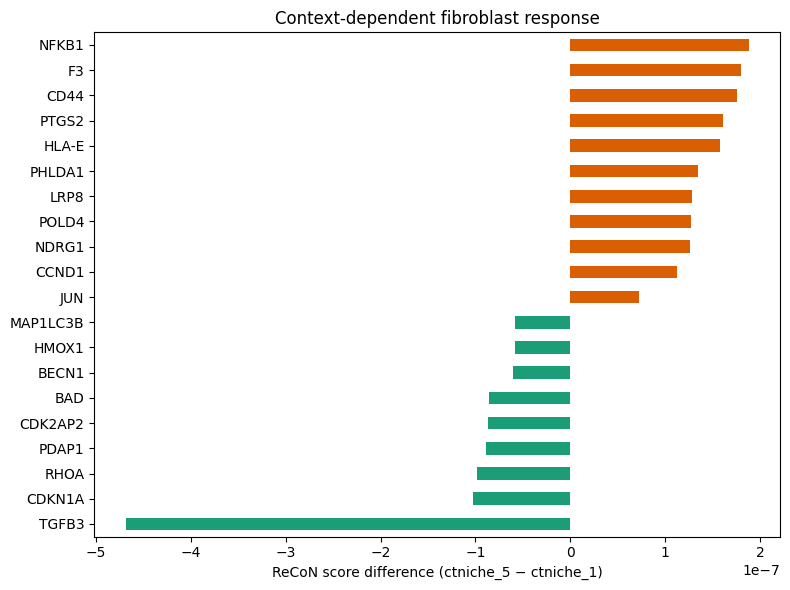

In [19]:
def fibroblast_profile(result, niche):
    ranked = result[result["multiplex"] == "Fibroblast_grn"].copy()
    ranked[["gene", "celltype"]] = ranked["node"].str.rsplit("::", n=1, expand=True)
    ranked = ranked.sort_values("score", ascending=False).drop_duplicates("gene")
    ranked[f"rank_{niche}"] = ranked["score"].rank(ascending=False, method="min")
    return ranked.set_index("gene")[["score", f"rank_{niche}"]].rename(
        columns={"score": f"score_{niche}"}
    )

comparison = fibroblast_profile(results[NICHES[0]], NICHES[0]).join(
    fibroblast_profile(results[NICHES[1]], NICHES[1]), how="outer"
).fillna(0)
comparison["score_difference"] = (
    comparison[f"score_{NICHES[1]}"] - comparison[f"score_{NICHES[0]}"]
)
comparison["rank_shift"] = (
    comparison[f"rank_{NICHES[0]}"] - comparison[f"rank_{NICHES[1]}"]
)
changed = comparison.loc[comparison["score_difference"].abs().nlargest(20).index]
plot_data = changed.sort_values("score_difference")
ax = plot_data["score_difference"].plot.barh(
    figsize=(8, 6),
    color=np.where(plot_data["score_difference"] > 0, "#d95f02", "#1b9e77"),
)
ax.set(xlabel=f"ReCoN score difference ({NICHES[1]} − {NICHES[0]})",
       ylabel="", title="Context-dependent fibroblast response")
plt.tight_layout()

We see that ReCoN attributes a much higher score for TGFB3 in the niche 5 (fibrotic) than in the niche 1 (healthy). It corresponds to what we could expect, as there is a known involvement of TGF-β signaling in fibroblast activation, myofibroblast differentiation, and extracellular-matrix remodeling.

```{warning}
**Interpretation caveat**

These are network-proximity scores, not differential-expression statistics or causal evidence. Validate candidates against expression, spatial localization, pathway enrichment, and independent experiments.
```

## Apply this workflow to your data

After validating this two-niche comparison, extend the same workflow to the other biologically characterized niches on your slide. Compare each niche against a meaningful reference context, check that candidate rankings are robust to the seed and network cutoffs, and use pathway enrichment to interpret groups of consistently shifted genes. The [full spatial heart showcase](https://github.com/cantinilab/recon_reproducibility/tree/main/showcases_paper/Spatial_Heart_Microenvironments) provides an example across niches 1, 2, 4, and 5.